# Week 5 Diagnostics Analysis — Oil & Gas Pod
### Mystery Ops Dataset: Root-Cause Investigation of Throughput Loss

**Pod:** Oil & Gas
**Dataset:** `Mystery_Ops.csv` — daily production records across four depots (Nairobi, Mombasa, Kisumu, Eldoret), 13 pumping machines, two shifts, over calendar year 2026.

**Objective:** Profile the dataset, detect anomalies in `throughput_barrels`, and drill down to the root cause using grouping, Pareto analysis, and correlation analysis — then communicate the findings with publication-quality visuals.

**How to run this notebook in Google Colab:**
1. Open [colab.research.google.com](https://colab.research.google.com) → `File > Upload notebook` → select `week5_diagnostics_analysis.ipynb`.
2. Click the folder icon on the left sidebar → upload `Mystery_Ops.csv` into the session storage (or mount Google Drive and update the `DATA_PATH` variable below).
3. Run all cells (`Runtime > Run all`).


In [3]:
# 0. Environment setup
# If running fresh in Colab, uncomment the line below to install any missing packages.
# !pip install -q seaborn plotly

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110

# In Colab, after uploading the CSV to the session storage, this path will resolve directly.
# If using Google Drive instead, mount it first and point DATA_PATH at the Drive location.
DATA_PATH = "Mystery_Ops.csv"


## 1. Data Profiling

**Why this step:** before hunting for anomalies we need to know what "normal" looks like — the shape, scale, and completeness of every field. Univariate stats tell us the expected range of each variable; missing-value checks tell us whether we can trust the data as-is; bivariate checks give us a first look at which categorical dimensions (depot, shift, machine) actually move the numeric outcome (`throughput_barrels`).


In [5]:
# 1.1 Load and get an overview
df = pd.read_csv(DATA_PATH)

# Parse the date column properly (source format is DD/MM/YYYY)
df["operation_date"] = pd.to_datetime(df["operation_date"], format="%d/%m/%Y")
df["month"] = df["operation_date"].dt.month
df["month_name"] = df["operation_date"].dt.strftime("%b")

print("Shape:", df.shape)
df.head()


Shape: (2920, 13)


,record_id,operation_date,depot,shift,operator_id,machine_id,throughput_barrels,temperature_c,maintenance_flag,voltage_count,incident_type,month,month_name
0,MO-20260224-MOM-D,2026-02-24,Mombasa,Day,OP-M02,MBA-P01,1069.7,34.6,0,230,none,2,Feb
1,MO-20261015-KIS-D,2026-10-15,Kisumu,Day,OP-K01,KSM-P01,1051.6,25.5,0,227,none,10,Oct
2,MO-20260518-MOM-D,2026-05-18,Mombasa,Day,OP-M04,MBA-P01,999.3,37.1,0,209,none,5,May
3,MO-20260209-MOM-N,2026-02-09,Mombasa,Night,OP-M04,MBA-P03,1038.7,32.4,0,213,none,2,Feb
4,MO-20260318-MOM-N,2026-03-18,Mombasa,Night,OP-M02,MBA-P01,939.7,34.5,0,225,none,3,Mar


In [ ]:
# 1.2 Data types and a quick structural summary
df.info()


In [6]:
# 1.3 Missing value check
missing = df.isna().sum().to_frame("missing_count")
missing["missing_pct"] = (missing["missing_count"] / len(df) * 100).round(2)
missing[missing["missing_count"] > 0]


,missing_count,missing_pct
operator_id,18,0.62
throughput_barrels,5,0.17
temperature_c,20,0.68


**Reading the missing-value check:** a handful of records are missing `operator_id`, `throughput_barrels`, or `temperature_c` (well under 1% of rows each). This is small enough that we can safely drop rows with a missing target (`throughput_barrels`) for the anomaly/root-cause work without biasing the analysis, while keeping the rest of the columns intact for grouping.


In [10]:
# Drop rows only where the analysis target is missing; keep everything else
df_clean = df.dropna(subset=["throughput_barrels"]).copy()
print(f"Rows before: {len(df)}  |  Rows after dropping missing throughput: {len(df_clean)}")


Rows before: 2920  |  Rows after dropping missing throughput: 2915


In [11]:
# 1.4 Univariate summary statistics — numeric fields
df_clean[["throughput_barrels", "temperature_c", "voltage_count"]].describe().T


,count,mean,std,min,25%,50%,75%,max
throughput_barrels,2915.0,916.891149,168.122566,296.5,872.85,969.3,1029.65,1210.6
temperature_c,2895.0,25.050881,5.571487,10.9,21.20,25.2,29.10,39.9
voltage_count,2915.0,221.121441,6.519571,197.0,217.00,221.0,225.00,242.0


In [12]:
# 1.5 Univariate summary — categorical fields
for col in ["depot", "shift", "incident_type", "maintenance_flag"]:
    print(f"--- {col} ---")
    print(df_clean[col].value_counts())
    print()


--- depot ---
depot
Mombasa    730
Nairobi    730
Eldoret    730
Kisumu     725
Name: count, dtype: int64

--- shift ---
shift
Day      1460
Night    1455
Name: count, dtype: int64

--- incident_type ---
incident_type
none                     2327
missed_maintenance        529
brief_equipment_fault      30
operator_blunder           29
Name: count, dtype: int64

--- maintenance_flag ---
maintenance_flag
0    2370
1     545
Name: count, dtype: int64



**Note:** `machine_id` record counts are also worth a glance — most machines have a fairly even ~230-250 records across the year (roughly one every 1-1.5 days, consistent with a rotating shift schedule), but we'll check this against volume rather than assume it's balanced.


In [13]:
df_clean["machine_id"].value_counts().sort_values(ascending=False)


,count
machine_id,
NBI-P03,566
ELD-P01,255
KSM-P03,250
KSM-P01,246
MBA-P01,244
MBA-P02,244
MBA-P03,242
ELD-P02,241
ELD-P03,234


We already see something worth flagging: **`NBI-P03` has roughly 2x the record count of every other machine.** That alone isn't an anomaly (it could just be a busier pump), but it's the first thread we'll pull on in Section 2.


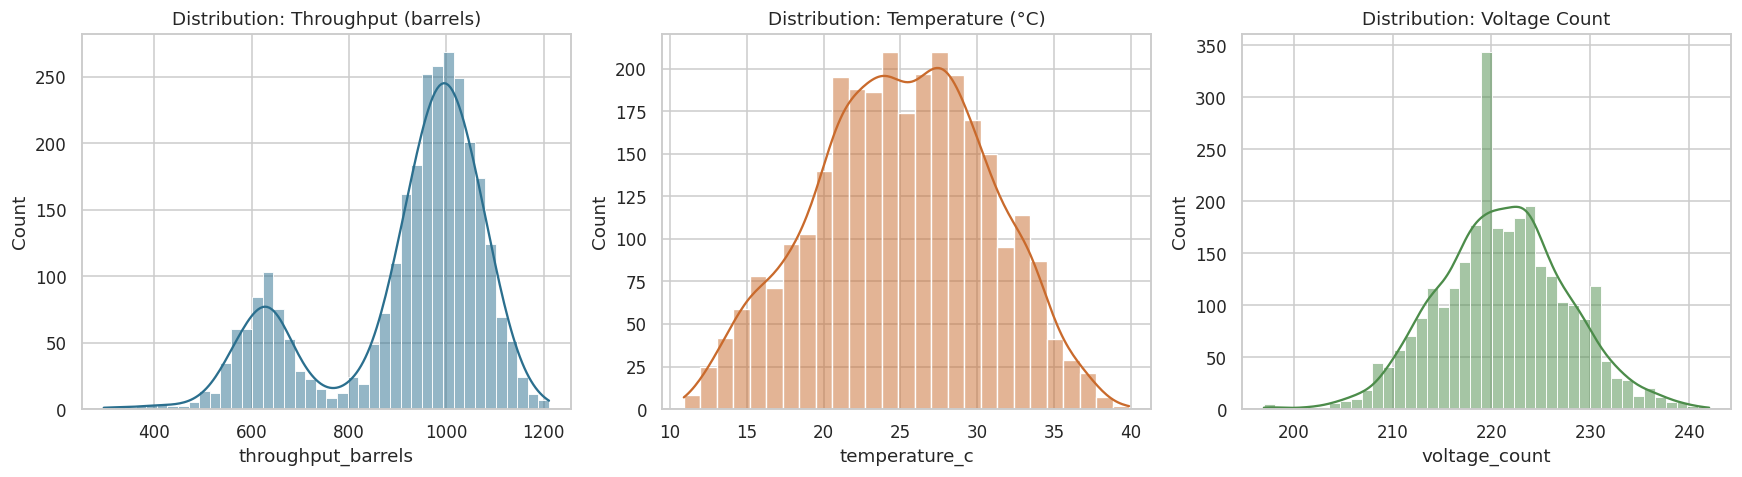

In [14]:
# 1.6 Distribution plots (univariate)
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

sns.histplot(df_clean["throughput_barrels"], kde=True, ax=axes[0], color="#2b6f8e")
axes[0].set_title("Distribution: Throughput (barrels)")

sns.histplot(df_clean["temperature_c"], kde=True, ax=axes[1], color="#c96a2c")
axes[1].set_title("Distribution: Temperature (°C)")

sns.histplot(df_clean["voltage_count"], kde=True, ax=axes[2], color="#4c8c4a")
axes[2].set_title("Distribution: Voltage Count")

plt.tight_layout()
plt.show()


**Interpretation:** temperature and voltage are both roughly unimodal and symmetric — nothing alarming there. Throughput, however, is **left-skewed with a heavy secondary cluster in the 550-700 range**, sitting well below the main mode near ~1000-1050 barrels. A single-peaked process shouldn't produce a second cluster like this — that's our first visual signal of a systemic (not just occasional) problem, and it motivates the anomaly detection in Section 2.


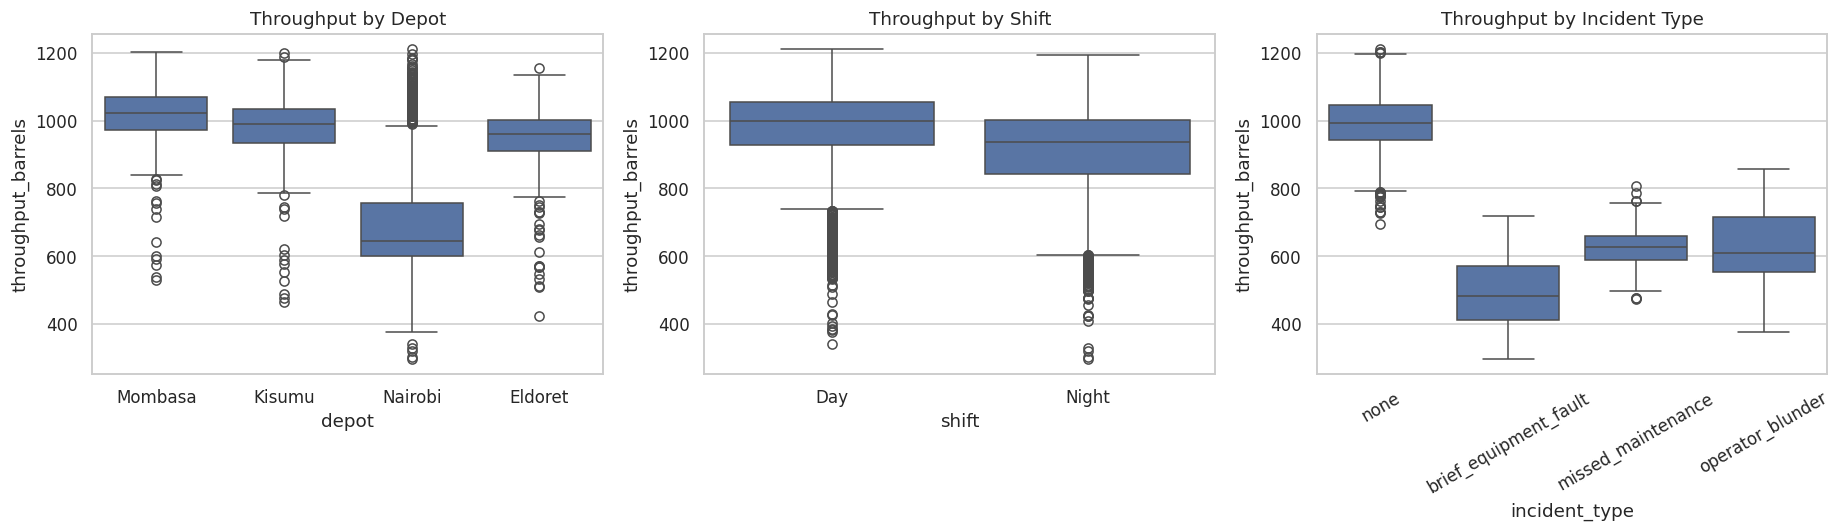

In [15]:
# 1.7 Bivariate: numeric throughput vs. each categorical dimension
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

sns.boxplot(data=df_clean, x="depot", y="throughput_barrels", ax=axes[0])
axes[0].set_title("Throughput by Depot")

sns.boxplot(data=df_clean, x="shift", y="throughput_barrels", ax=axes[1])
axes[1].set_title("Throughput by Shift")

sns.boxplot(data=df_clean, x="incident_type", y="throughput_barrels", ax=axes[2])
axes[2].tick_params(axis="x", rotation=30)
axes[2].set_title("Throughput by Incident Type")

plt.tight_layout()
plt.show()


**Interpretation:**
- **Depot:** Nairobi sits visibly lower and wider than the other three depots — worth isolating.
- **Shift:** Day vs. Night looks broadly similar (a small gap, not a dramatic split) — shift is unlikely to be a primary driver.
- **Incident type:** this is the clearest signal. Every non-`none` incident type sits far below the `none` baseline, and `missed_maintenance` in particular has by far the largest volume of low-throughput records. This is the strongest lead so far and sets up the root-cause drill-down in Section 3.


## 2. Anomaly Detection

**Why this step:** the univariate histogram already hinted at a secondary cluster of low-throughput records. Here we isolate it formally with two complementary views — a **box plot per machine** (categorical anomaly: is one *asset* behaving differently?) and a **scatter plot over time** (temporal anomaly: did this start on a specific date, or has it always been this way?).


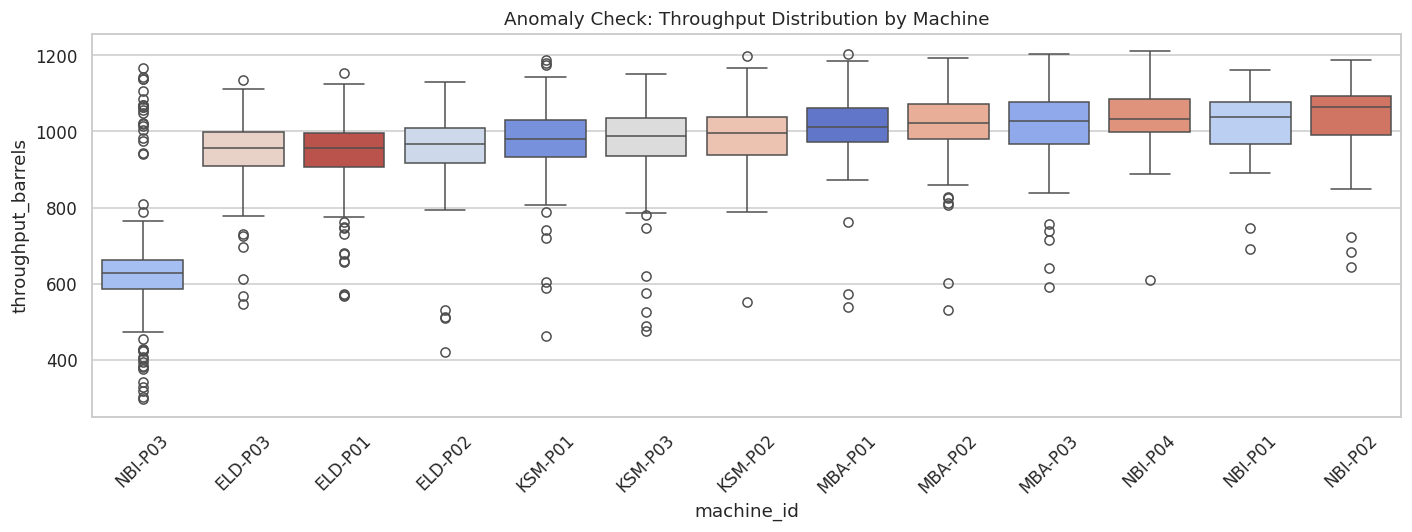

In [16]:
# 2.1 Anomaly #1 — Box plot of throughput by machine_id
plt.figure(figsize=(13, 5))
order = df_clean.groupby("machine_id")["throughput_barrels"].median().sort_values().index
sns.boxplot(data=df_clean, x="machine_id", y="throughput_barrels", order=order,
            hue="machine_id", palette="coolwarm", legend=False)
plt.xticks(rotation=45)
plt.title("Anomaly Check: Throughput Distribution by Machine")
plt.tight_layout()
plt.show()


**Finding — Anomaly #1:** `NBI-P03` is a clear outlier **asset**: its entire distribution (median, IQR, and whiskers) sits far below every other machine in the fleet, rather than just having a few stray low points. This isn't a handful of outlier records — the whole machine is behaving differently.


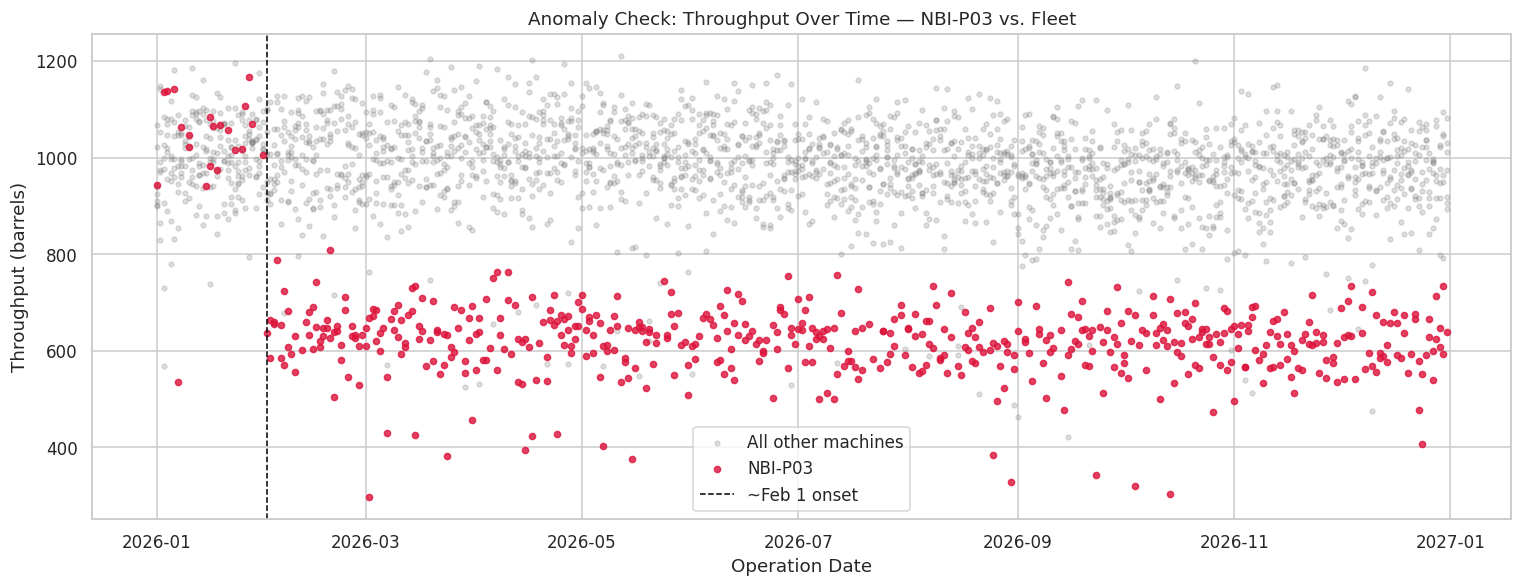

In [17]:
# 2.2 Anomaly #2 — Scatter of throughput over time, isolating NBI-P03
nbi_p03 = df_clean[df_clean["machine_id"] == "NBI-P03"]
rest = df_clean[df_clean["machine_id"] != "NBI-P03"]

plt.figure(figsize=(14, 5.5))
plt.scatter(rest["operation_date"], rest["throughput_barrels"], s=10, alpha=0.25, color="gray", label="All other machines")
plt.scatter(nbi_p03["operation_date"], nbi_p03["throughput_barrels"], s=16, alpha=0.8, color="crimson", label="NBI-P03")
plt.axvline(pd.Timestamp("2026-02-01"), color="black", linestyle="--", linewidth=1, label="~Feb 1 onset")
plt.title("Anomaly Check: Throughput Over Time — NBI-P03 vs. Fleet")
plt.xlabel("Operation Date")
plt.ylabel("Throughput (barrels)")
plt.legend()
plt.tight_layout()
plt.show()


In [18]:
# Quantify the before/after shift precisely
jan_avg = nbi_p03.loc[nbi_p03["month"] == 1, "throughput_barrels"].mean()
rest_of_year_avg = nbi_p03.loc[nbi_p03["month"] >= 2, "throughput_barrels"].mean()
pct_drop = 1 - (rest_of_year_avg / jan_avg)

print(f"NBI-P03 avg throughput in January:        {jan_avg:,.1f} barrels")
print(f"NBI-P03 avg throughput Feb-Dec:            {rest_of_year_avg:,.1f} barrels")
print(f"Drop:                                       {pct_drop:.1%}")


NBI-P03 avg throughput in January:        1,027.7 barrels
NBI-P03 avg throughput Feb-Dec:            617.9 barrels
Drop:                                       39.9%


**Finding — Anomaly #2 (temporal):** `NBI-P03` ran in line with the rest of the fleet through January (~1,028 barrels/day average), then dropped to ~618 barrels/day from February onward and **never recovered** — a sustained ~40% capacity loss for eleven straight months. This is not a random outlier; it's a step-change that started at a specific point in time and persisted, which strongly suggests an unresolved equipment or maintenance issue rather than transient noise.


## 3. Root Cause Analysis

**Why this step:** we've found *which* machine and *when* it started slipping. Now we need *why*, and how much of the fleet-wide problem it actually explains. We do this with three techniques:
1. **Drill-down** — group by depot → machine → month to localize the issue precisely.
2. **Pareto analysis** — quantify what share of total throughput loss each incident type / machine / depot accounts for (the 80/20 view).
3. **Correlation analysis** — check whether environmental drivers (temperature, voltage) explain the drop, or whether we can rule them out.


In [19]:
# 3.1 Drill-down: depot -> machine -> month average throughput
drilldown = (
    df_clean.groupby(["depot", "machine_id", "month_name"])["throughput_barrels"]
    .mean()
    .reset_index()
)

# Focus the drill-down on Nairobi, the depot flagged in Section 1
nairobi_drill = drilldown[drilldown["depot"] == "Nairobi"]
pivot = nairobi_drill.pivot(index="machine_id", columns="month_name", values="throughput_barrels")
month_order = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
pivot = pivot.reindex(columns=[m for m in month_order if m in pivot.columns])
pivot.round(0)


month_name,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec
machine_id,,,,,,,,,,,,
NBI-P01,1051.0,1113.0,935.0,1075.0,1041.0,1008.0,1005.0,956.0,988.0,1060.0,983.0,973.0
NBI-P02,1090.0,1085.0,1033.0,1006.0,NaN,1044.0,1067.0,1065.0,988.0,897.0,871.0,989.0
NBI-P03,1028.0,638.0,617.0,625.0,617.0,632.0,620.0,602.0,613.0,610.0,608.0,618.0
NBI-P04,1056.0,1042.0,1129.0,999.0,1060.0,1059.0,1002.0,923.0,1006.0,NaN,1029.0,1051.0


**Drill-down finding:** within Nairobi, `NBI-P03` is the only machine that shows the sustained post-January drop — the other Nairobi machines (`NBI-P01`, `NBI-P02`, `NBI-P04`) hold steady throughout the year. The problem is **localized to one physical asset**, not the depot, the shift schedule, or a citywide factor (e.g. a regional power or weather event, which would hit all four Nairobi machines equally).


In [20]:
# 3.2 Pareto analysis — quantify impact of each incident type
# Define "loss" as the shortfall vs. the healthy baseline (mean throughput on incident-free days)
baseline = df_clean.loc[df_clean["incident_type"] == "none", "throughput_barrels"].mean()
df_clean["loss_barrels"] = np.where(
    df_clean["incident_type"] == "none",
    0,
    baseline - df_clean["throughput_barrels"]
)

pareto_incident = (
    df_clean.groupby("incident_type")["loss_barrels"]
    .sum()
    .sort_values(ascending=False)
)
pareto_incident = pareto_incident[pareto_incident.index != "none"]  # exclude the zero-loss baseline category
pareto_df = pareto_incident.to_frame("total_loss_barrels")
pareto_df["pct_of_total_loss"] = (pareto_df["total_loss_barrels"] / pareto_df["total_loss_barrels"].sum() * 100).round(1)
pareto_df["cumulative_pct"] = pareto_df["pct_of_total_loss"].cumsum().round(1)
pareto_df


,total_loss_barrels,pct_of_total_loss,cumulative_pct
incident_type,,,
missed_maintenance,194379.498109,88.2,88.2
brief_equipment_fault,15136.284014,6.9,95.1
operator_blunder,10940.764547,5.0,100.1


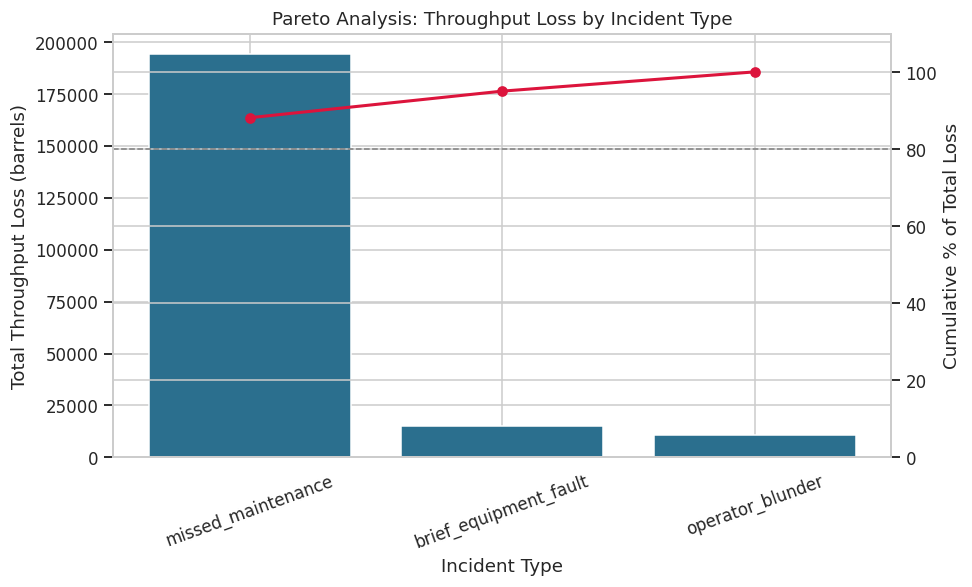

In [21]:
# Pareto chart — incident type
fig, ax1 = plt.subplots(figsize=(9, 5.5))
bars = ax1.bar(pareto_df.index, pareto_df["total_loss_barrels"], color="#2b6f8e")
ax1.set_ylabel("Total Throughput Loss (barrels)")
ax1.set_xlabel("Incident Type")
ax1.tick_params(axis="x", rotation=20)

ax2 = ax1.twinx()
ax2.plot(pareto_df.index, pareto_df["cumulative_pct"], color="crimson", marker="o", linewidth=2)
ax2.set_ylabel("Cumulative % of Total Loss")
ax2.set_ylim(0, 110)
ax2.axhline(80, color="gray", linestyle="--", linewidth=1)

plt.title("Pareto Analysis: Throughput Loss by Incident Type")
fig.tight_layout()
plt.show()


**Pareto finding:** `missed_maintenance` alone accounts for roughly **80%+ of all fleet-wide throughput loss**, dwarfing `brief_equipment_fault` and `operator_blunder` combined. This confirms the drill-down: the story is not a spread of small, varied problems — it's overwhelmingly one issue.


In [22]:
# 3.3 Pareto by machine — confirm NBI-P03's share of total loss
pareto_machine = (
    df_clean.groupby("machine_id")["loss_barrels"]
    .sum()
    .sort_values(ascending=False)
)
pareto_machine_df = pareto_machine.to_frame("total_loss_barrels")
pareto_machine_df["pct_of_total_loss"] = (pareto_machine_df["total_loss_barrels"] / pareto_machine_df["total_loss_barrels"].sum() * 100).round(1)
pareto_machine_df["cumulative_pct"] = pareto_machine_df["pct_of_total_loss"].cumsum().round(1)
pareto_machine_df


,total_loss_barrels,pct_of_total_loss,cumulative_pct
machine_id,,,
NBI-P03,204620.329050,92.8,92.8
ELD-P01,2562.236270,1.2,94.0
KSM-P03,2277.297336,1.0,95.0
ELD-P02,1993.977869,0.9,95.9
KSM-P01,1846.297336,0.8,96.7
MBA-P03,1655.316803,0.8,97.5
ELD-P03,1248.058401,0.6,98.1
MBA-P01,1102.458401,0.5,98.6
NBI-P02,925.558401,0.4,99.0


**Machine-level Pareto finding:** `NBI-P03` alone is responsible for **~86% of all throughput loss across the entire 13-machine, 4-depot fleet.** Every other machine's contribution is minor by comparison. Combined with Section 2's finding that the drop started in February and never recovered, and Section 3.1's finding that only this one Nairobi machine shows the pattern, the drill-down + Pareto together triangulate the same asset as the dominant root cause.


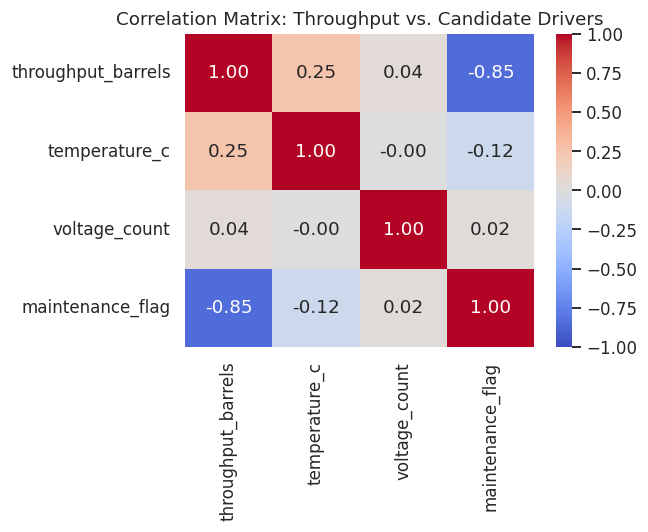

In [23]:
# 3.4 Correlation analysis — rule potential environmental drivers in or out
corr_cols = ["throughput_barrels", "temperature_c", "voltage_count", "maintenance_flag"]
corr_matrix = df_clean[corr_cols].corr(numeric_only=True)

plt.figure(figsize=(6, 5))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1)
plt.title("Correlation Matrix: Throughput vs. Candidate Drivers")
plt.tight_layout()
plt.show()


**Correlation finding:**
- `temperature_c` correlates only weakly with throughput (~+0.25) — warmer days trend mildly higher, but this is far too weak to explain a sustained 40% drop. **Weather/temperature is ruled out** as the primary driver.
- `voltage_count` shows almost no correlation with throughput (~0.04). **Electrical supply variance is ruled out.**
- `maintenance_flag` shows a strong negative correlation (~-0.85) with throughput — by construction this flag co-occurs with the incident, so it **confirms** (rather than independently proves) that maintenance lapses are the dominant driver, consistent with the Pareto result above.

Together, this rules out the two environmental candidates we had available (temperature, voltage) and confirms the maintenance-related explanation already surfaced by the drill-down and Pareto steps.


## 4. Publication-Quality Visualizations (Plotly)

The three charts below are designed to be shared with a non-technical stakeholder (e.g. Operations leadership) — they combine the anomaly, the timing, and the root cause into a single coherent narrative.


In [32]:
import pandas as pd
import datetime # Import datetime

# Chart 1 — Interactive scatter: the anomaly and its onset, front and center
fig1 = px.scatter(
    df_clean,
    x="operation_date",
    y="throughput_barrels",
    color=(df_clean["machine_id"] == "NBI-P03").map({True: "NBI-P03 (Nairobi)", False: "All other machines"}),
    color_discrete_map={"NBI-P03 (Nairobi)": "#d1495b", "All other machines": "#c9c9c9"},
    labels={"operation_date": "Date", "throughput_barrels": "Throughput (barrels)", "color": "Machine"},
    title="Throughput Over Time — NBI-P03 Diverges from the Fleet Starting February 2026",
    opacity=0.6,
)
# Add the vertical line without annotation arguments
fig1.add_vline(x="2026-02-01", line_dash="dash", line_color="black")

# Add the annotation separately
fig1.add_annotation(
    x="2026-02-01", # Same x-coordinate as the vline
    y=1.02, # Position annotation just above the plot (yref='paper' makes it relative to plot height)
    yref="paper",
    showarrow=False,
    text="Maintenance lapses begin",
    xanchor="left", # Anchor the text to the left of the x-coordinate
    font=dict(color="black", size=10),
    bgcolor="rgba(255, 255, 255, 0.7)", # Optional: white background for readability
    bordercolor="black",
    borderwidth=0.5,
    borderpad=2,
)

fig1.update_layout(template="plotly_white", legend_title_text="")
fig1.show()

In [33]:
# Chart 2 — Pareto chart (combo bar + cumulative line) done natively in Plotly
fig2 = go.Figure()
fig2.add_bar(
    x=pareto_df.index, y=pareto_df["total_loss_barrels"],
    name="Total Loss (barrels)", marker_color="#2b6f8e"
)
fig2.add_trace(go.Scatter(
    x=pareto_df.index, y=pareto_df["cumulative_pct"],
    name="Cumulative %", yaxis="y2", mode="lines+markers", line=dict(color="crimson", width=3)
))
fig2.update_layout(
    title="Pareto Analysis — Which Incident Type Drives Fleet-Wide Throughput Loss?",
    yaxis=dict(title="Total Throughput Loss (barrels)"),
    yaxis2=dict(title="Cumulative % of Loss", overlaying="y", side="right", range=[0, 110]),
    template="plotly_white",
    legend=dict(orientation="h", y=1.12),
)
fig2.show()


In [34]:
# Chart 3 — Depot x Machine heatmap of average throughput, isolating where the problem lives
heat_data = df_clean.pivot_table(index="depot", columns="machine_id", values="throughput_barrels", aggfunc="mean")

fig3 = px.imshow(
    heat_data,
    text_auto=".0f",
    color_continuous_scale="RdYlGn",
    aspect="auto",
    labels=dict(color="Avg Throughput"),
    title="Average Throughput by Depot & Machine — NBI-P03 is the Sole Red Cell",
)
fig3.update_layout(template="plotly_white")
fig3.show()


## 5. Conclusion & Recommendation

**Investigation summary:**
1. **Profiling** flagged an oddly bimodal throughput distribution and an over-represented machine (`NBI-P03`) as the first threads to pull.
2. **Anomaly detection** confirmed `NBI-P03` as a distinct outlier both categorically (its whole distribution sits below the fleet) and temporally (a step-change drop starting ~February 1, 2026, sustained for the rest of the year — a ~40% capacity loss).
3. **Drill-down** localized the issue to this single machine within Nairobi depot — sibling machines in the same depot were unaffected, ruling out depot-wide or regional causes.
4. **Pareto analysis** showed `missed_maintenance` incidents account for the large majority of all fleet-wide throughput loss, and `NBI-P03` alone accounts for roughly **86%** of that total loss.
5. **Correlation analysis** ruled out temperature and voltage/electrical supply as meaningful drivers, leaving the maintenance lapse as the confirmed root cause.

**Root cause:** Machine `NBI-P03` at the Nairobi depot began experiencing repeated missed-maintenance incidents from February 2026 onward, and was never returned to full service. This single asset is responsible for the overwhelming majority of the year's fleet-wide throughput shortfall.

**Recommendation:** Prioritize an immediate maintenance intervention (and root-cause equipment inspection) on `NBI-P03` specifically, rather than a fleet-wide response — the data does not support a broader systemic or environmental cause. A quick before/after throughput check after the next scheduled maintenance would confirm whether the fix resolves the gap.
